In [ ]:
# =========================================================
# Pre-announcement Fixed Cohort Analysis
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
# =========================================================
# 1. Paths and Dates
# =========================================================

BASE_DIR = Path(".")
MERGED_VIDEOS_PATH = BASE_DIR / "merged_videos.csv"

OUTPUT_DIR = BASE_DIR / "pre_announcement_fixed_cohort_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 전체 분석 기간
ANALYSIS_START_RAW = pd.Timestamp("2023-09-01", tz="UTC")
ANALYSIS_END_RAW   = pd.Timestamp("2026-01-31 23:59:59", tz="UTC")

# 정책 날짜
PRE_ANNOUNCEMENT_DATE = pd.Timestamp("2023-11-14", tz="UTC")
POLICY_DATE           = pd.Timestamp("2024-03-18", tz="UTC")
POLICY2_DATE          = pd.Timestamp("2025-07-15", tz="UTC")

# Fixed cohort 정의 기간
PRE_ACTIVE_START = pd.Timestamp("2023-09-01", tz="UTC")
PRE_ACTIVE_END   = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")

print("Input file:", MERGED_VIDEOS_PATH)
print("Output directory:", OUTPUT_DIR)

Input file: merged_videos.csv
Output directory: pre_announcement_fixed_cohort_outputs


In [3]:
# =========================================================
# 2. Helper Functions
# =========================================================

def ensure_utc_datetime(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


def first_full_monday(start_ts):
    """
    분석 시작일 이후 첫 번째 월요일을 반환.
    2023-09-01은 금요일이므로 첫 완전 주는 2023-09-04부터 시작.
    """
    ts = pd.Timestamp(start_ts)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")

    ts = ts.normalize()
    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def week_start_monday(series):
    """
    published_at 기준 월요일 week_start 생성.
    """
    s = ensure_utc_datetime(series)
    return (s - pd.to_timedelta(s.dt.weekday, unit="D")).dt.normalize()


def calculate_hhi_from_counts(counts):
    """
    HHI = sum(channel upload share^2)
    """
    x = pd.Series(counts).dropna().astype(float)
    total = x.sum()

    if total <= 0:
        return np.nan

    shares = x / total
    return float((shares ** 2).sum())


def calculate_gini_from_counts(counts):
    """
    Gini coefficient.
    fixed cohort 분석에서는 업로드가 없는 채널도 0으로 포함.
    """
    x = np.asarray(counts, dtype=float)
    x = x[~np.isnan(x)]

    if len(x) == 0:
        return np.nan

    if np.sum(x) <= 0:
        return np.nan

    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)

    return float((n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n)


def complete_weekly_series(df, week_col, fill_cols=None):
    """
    첫 완전 주부터 분석 종료 주까지 모든 주 생성.
    없는 주는 fill_cols에 한해 0으로 채움.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday(ANALYSIS_START_RAW)
    end_week = first_full_monday(ANALYSIS_END_RAW)

    full_weeks = pd.date_range(
        start=start_week,
        end=end_week,
        freq="W-MON",
        tz="UTC"
    )

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .rename_axis(week_col)
           .reset_index()
    )

    if fill_cols is not None:
        for col in fill_cols:
            if col in out.columns:
                out[col] = out[col].fillna(0)

    return out


def add_policy_lines(ax):
    """
    정책 예고일, 정책 시행일, 수익 제재 정책일 표시.
    """
    announce_x = PRE_ANNOUNCEMENT_DATE.tz_localize(None)
    policy_x = POLICY_DATE.tz_localize(None)
    policy2_x = POLICY2_DATE.tz_localize(None)

    ax.axvline(announce_x, linestyle="--", linewidth=1.5)
    ax.axvline(policy_x, linestyle="--", linewidth=1.5)
    ax.axvline(policy2_x, linestyle=":", linewidth=1.5)

    ymin, ymax = ax.get_ylim()

    ax.text(
        announce_x,
        ymax,
        "Announcement\n2023-11-14",
        ha="left",
        va="top",
        fontsize=9
    )

    ax.text(
        policy_x,
        ymax,
        "Policy\n2024-03-18",
        ha="left",
        va="top",
        fontsize=9
    )

    ax.text(
        policy2_x,
        ymax,
        "Monetization\n2025-07-15",
        ha="left",
        va="top",
        fontsize=9
    )


def format_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()


def save_figure(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure:", path)

In [4]:
# =========================================================
# 3. Load merged_videos.csv
# =========================================================

if not MERGED_VIDEOS_PATH.exists():
    raise FileNotFoundError(f"Cannot find file: {MERGED_VIDEOS_PATH}")

raw = pd.read_csv(MERGED_VIDEOS_PATH, low_memory=False)

print("Raw shape:", raw.shape)
print("Columns:")
print(raw.columns.tolist())

display(raw.head())

Raw shape: (385314, 15)
Columns:
['channel_id', 'collected_at_utc', 'duration_sec', 'is_ai_cover', 'like_count', 'published_at', 'source', 'video_description', 'video_id', 'video_tags', 'video_title', 'view_count', 'week_start_date', 'weeks_from_policy1', 'weeks_from_policy2']


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,source,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2
0,UC-DadGUHxVxgs_gwadyf5VQ,2026-04-12T17:01:13.372151+00:00,318.0,0,2085.0,2024-01-23 13:14:28+00:00,2.0,#kangenband #karaokehits #karaoke \n\nSawer yu...,--3m-wH7xVo,kangen band karaoke | karaoke pop Indonesia | ...,KANGEN BAND_ TENTANG JEN (TENTANG KEKASIHNYA) ...,585911.0,2024-01-22,-7.86,-77.00
1,UCXH5zvXxrtrU0WDBZfF7gnA,2026-04-12T17:02:09.801931+00:00,256.0,1,3.0,2025-06-02 12:02:24+00:00,2.0,#ai #jpop #노래 #음악 #remix \n\nNIKI - ERROR,f2vSVwk7v3Y,NaN,(AI Cover) - ERROR Remix,172.0,2025-06-02,63.00,-6.14
2,UC7gxVR7qQpedta0Rx4Q_E2Q,2026-04-12T17:02:09.801931+00:00,277.0,1,156.0,2024-01-03 13:11:43+00:00,2.0,#nikeardilla #aicover #berlayartakbertepian,f3aqRcr6B3Q,NaN,Nike Ardilla - Berlayar tak bertepian (ai Cover),20317.0,2024-01-01,-10.71,-79.86
3,UCV2zUIYSXFIKS_3Hcc1O1VQ,2026-04-12T17:02:09.801931+00:00,185.0,1,121.0,2025-07-25 02:48:19+00:00,2.0,#GirlsGeneration #LineDistribution,f3fr4HAi_kQ,Line Distribution,[AI COVER] I AM - Girls' Generation (OT9) (Org...,2245.0,2025-07-21,70.57,1.43
4,UC_jf2E1X5JkNKQM_m_tAjxg,2026-04-12T17:02:09.801931+00:00,149.0,1,477.0,2024-07-04 09:00:29+00:00,2.0,#하니 #양홍원 #jealousyvalhalla #hanni #slowmo #슬로모...,f3uc-cQoq4M,하니 | 양홍원 | jealousyvalhalla | hanni | slowmo |...,하니 (HANNI) - JEALOUSYVALHALLA (양홍원) (AI Cover),35851.0,2024-07-01,15.43,-53.71


In [5]:
# =========================================================
# 4. Clean Dataset
# =========================================================

required_cols = [
    "video_id",
    "channel_id",
    "published_at",
    "is_ai_cover"
]

missing_cols = [c for c in required_cols if c not in raw.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in merged_videos.csv: {missing_cols}")

df = raw.copy()

df["video_id"] = df["video_id"].astype(str).str.strip()
df["channel_id"] = df["channel_id"].astype(str).str.strip()
df["published_at"] = ensure_utc_datetime(df["published_at"])

df["is_ai_cover"] = (
    pd.to_numeric(df["is_ai_cover"], errors="coerce")
      .fillna(0)
      .astype(int)
)

# 필수값 없는 행 제거
df = df.dropna(subset=["video_id", "channel_id", "published_at"]).copy()

# video_id 중복 제거
df = (
    df.sort_values("published_at")
      .drop_duplicates(subset=["video_id"], keep="first")
      .reset_index(drop=True)
)

print("Unique videos after dedup:", len(df))
display(df.head())

Unique videos after dedup: 385260


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,source,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2
0,UCXAT5oVadTLwGTWbbRZcPYw,2026-04-13T07:24:15.836779+00:00,177.0,1,41.0,2023-09-01 00:10:45+00:00,5.0,Thought this song fits Eddy REALLY well LOL\nP...,xd666nEY7g8,[error],[The Lorax 2012] - How Bad Can I Be ft. Eddy (...,2670.0,2023-08-28,-28.43,-97.57
1,UCDrfjsszTsV8SwXheMDL6ug,2026-04-13T04:16:44.219232+00:00,11.0,0,30.0,2023-09-01 00:19:12+00:00,5.0,NaN,Zc5HZ6u0qW0,NaN,The Super Hero Squad Show - Disney XD Intermis...,3136.0,2023-08-28,-28.43,-97.57
2,UC7YOG9r-lbLIYiVYRrTtrnQ,2026-04-13T04:14:32.640063+00:00,34.0,0,26.0,2023-09-01 00:20:18+00:00,5.0,CC:Rutson on Discord and YouTube:https://www.y...,XjWajSXo_Qg,NaN,BTS - Danger(EXO Ot12 AI)Teaser,698.0,2023-08-28,-28.43,-97.57
3,UCFWyxmLGaqn7s2sK02TSHIA,2026-04-13T04:17:18.009459+00:00,11.0,0,1353.0,2023-09-01 00:29:32+00:00,5.0,#riize #라이즈 #라이즈원빈 #원빈 #원빈사투리 #라이즈원빈사투리 #원빈울산 ...,_5LtPLa4ygo,사투리 쓰는 아이돌 | 아이돌 사투리 | 라이즈 원빈 사투리 | 원빈 울산 사투리 ...,라이즈 원빈 울산 사투리,42433.0,2023-08-28,-28.43,-97.57
4,UCJquYOG5EL82sKTfH9aMA9Q,2026-04-13T07:18:08.896805+00:00,32.0,0,41683.0,2023-09-01 00:40:11+00:00,5.0,NaN,sZv2EogtWJg,NaN,Reaction Dua Lipa “Dance the Night” #dualipa #...,1392912.0,2023-08-28,-28.43,-97.57


In [6]:
# =========================================================
# 4. Clean Dataset
# =========================================================

required_cols = [
    "video_id",
    "channel_id",
    "published_at",
    "is_ai_cover"
]

missing_cols = [c for c in required_cols if c not in raw.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in merged_videos.csv: {missing_cols}")

df = raw.copy()

df["video_id"] = df["video_id"].astype(str).str.strip()
df["channel_id"] = df["channel_id"].astype(str).str.strip()
df["published_at"] = ensure_utc_datetime(df["published_at"])

df["is_ai_cover"] = (
    pd.to_numeric(df["is_ai_cover"], errors="coerce")
      .fillna(0)
      .astype(int)
)

# 필수값 없는 행 제거
df = df.dropna(subset=["video_id", "channel_id", "published_at"]).copy()

# video_id 중복 제거
df = (
    df.sort_values("published_at")
      .drop_duplicates(subset=["video_id"], keep="first")
      .reset_index(drop=True)
)

print("Unique videos after dedup:", len(df))
display(df.head())

Unique videos after dedup: 385260


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,source,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2
0,UCXAT5oVadTLwGTWbbRZcPYw,2026-04-13T07:24:15.836779+00:00,177.0,1,41.0,2023-09-01 00:10:45+00:00,5.0,Thought this song fits Eddy REALLY well LOL\nP...,xd666nEY7g8,[error],[The Lorax 2012] - How Bad Can I Be ft. Eddy (...,2670.0,2023-08-28,-28.43,-97.57
1,UCDrfjsszTsV8SwXheMDL6ug,2026-04-13T04:16:44.219232+00:00,11.0,0,30.0,2023-09-01 00:19:12+00:00,5.0,NaN,Zc5HZ6u0qW0,NaN,The Super Hero Squad Show - Disney XD Intermis...,3136.0,2023-08-28,-28.43,-97.57
2,UC7YOG9r-lbLIYiVYRrTtrnQ,2026-04-13T04:14:32.640063+00:00,34.0,0,26.0,2023-09-01 00:20:18+00:00,5.0,CC:Rutson on Discord and YouTube:https://www.y...,XjWajSXo_Qg,NaN,BTS - Danger(EXO Ot12 AI)Teaser,698.0,2023-08-28,-28.43,-97.57
3,UCFWyxmLGaqn7s2sK02TSHIA,2026-04-13T04:17:18.009459+00:00,11.0,0,1353.0,2023-09-01 00:29:32+00:00,5.0,#riize #라이즈 #라이즈원빈 #원빈 #원빈사투리 #라이즈원빈사투리 #원빈울산 ...,_5LtPLa4ygo,사투리 쓰는 아이돌 | 아이돌 사투리 | 라이즈 원빈 사투리 | 원빈 울산 사투리 ...,라이즈 원빈 울산 사투리,42433.0,2023-08-28,-28.43,-97.57
4,UCJquYOG5EL82sKTfH9aMA9Q,2026-04-13T07:18:08.896805+00:00,32.0,0,41683.0,2023-09-01 00:40:11+00:00,5.0,NaN,sZv2EogtWJg,NaN,Reaction Dua Lipa “Dance the Night” #dualipa #...,1392912.0,2023-08-28,-28.43,-97.57


In [7]:
# =========================================================
# 5. Filter AI Cover Videos and Analysis Window
# =========================================================

# AI cover 영상만 사용
ai_all = df[df["is_ai_cover"] == 1].copy()

# week 생성
ai_all["week"] = week_start_monday(ai_all["published_at"])

# 전체 분석 기간 제한
ai_window = ai_all[
    (ai_all["published_at"] >= ANALYSIS_START_RAW) &
    (ai_all["published_at"] <= ANALYSIS_END_RAW)
].copy()

# 첫 불완전 주 제거
first_week = first_full_monday(ANALYSIS_START_RAW)
ai_window = ai_window[ai_window["week"] >= first_week].copy()

print("AI cover videos:", len(ai_all))
print("AI cover videos in analysis window:", len(ai_window))
print("First full analysis week:", first_week)
print("Last observed week:", ai_window["week"].max())

display(ai_window.head())

AI cover videos: 118693
AI cover videos in analysis window: 118398
First full analysis week: 2023-09-04 00:00:00+00:00
Last observed week: 2026-01-26 00:00:00+00:00


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,source,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2,week
943,UCsY1MZo3R_XrpoGQBEbUkag,2026-04-13T04:25:04.592868+00:00,242.0,1,5101.0,2023-09-04 00:00:12+00:00,5.0,EVERY. SINGLE. ADLIB. FILTERED. that high note...,fh-7nfl9Zm4,NaN,[AI COVER] How would TWICE sing ‘The Boys’ by ...,84676.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
949,UCWf0Gn3_kfaGu-rMTi24vkw,2026-04-13T07:26:39.978495+00:00,101.0,1,14.0,2023-09-04 00:30:31+00:00,5.0,"Why he sound so ""yeehaw"" 😭😭😭\nBarney when he s...",zjJvD9CIOiw,NaN,Barney Calhoun - What Hurts The Most [AI Cover],835.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
956,UCtCdA66A5Y5kvYHy0Sgg5VQ,2026-04-13T07:22:22.946416+00:00,356.0,1,22.0,2023-09-04 01:24:19+00:00,5.0,NaN,w4-Oq-YPZx0,Persona 3 | Persona 4 | Persona 5 Royal | Pers...,[Persona AI] Persona 3 - Kimi no Kioku | AI Co...,1045.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
957,UCtCdA66A5Y5kvYHy0Sgg5VQ,2026-04-13T03:36:31.246154+00:00,356.0,1,46.0,2023-09-04 01:24:22+00:00,5.0,NaN,13S0Qwv2r7A,Persona 3 | Persona 4 | Persona 5 Royal | Pers...,[Persona AI] Persona 3 - Kimi no Kioku | AI Co...,1351.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
958,UCtCdA66A5Y5kvYHy0Sgg5VQ,2026-04-13T04:26:03.193669+00:00,356.0,1,22.0,2023-09-04 01:24:25+00:00,5.0,Ahora todos los miembros de S.E.E.S tienen su ...,gW0FgwfMiy0,Persona 3 | Persona 4 | Persona 5 Royal | Pers...,[Persona AI] Persona 3 - Kimi no Kioku | AI Co...,659.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00


In [8]:
# =========================================================
# 6. Define Pre-announcement Fixed Cohort
# =========================================================
# Fixed cohort:
# 2023-09-01 ~ 2023-11-13 사이 AI cover를 1개 이상 올린 채널

pre_period_ai = ai_all[
    (ai_all["published_at"] >= PRE_ACTIVE_START) &
    (ai_all["published_at"] <= PRE_ACTIVE_END)
].copy()

pre_announcement_fixed_cohort_ids = set(
    pre_period_ai["channel_id"].dropna().astype(str).unique()
)

cohort_size = len(pre_announcement_fixed_cohort_ids)

print("Pre-announcement fixed cohort size:", cohort_size)
print("Pre-period AI cover uploads:", len(pre_period_ai))
print("Pre-period active channels:", pre_period_ai["channel_id"].nunique())

# 분석 기간 전체에서 fixed cohort 채널만 유지
cohort_ai_window = ai_window[
    ai_window["channel_id"].astype(str).isin(pre_announcement_fixed_cohort_ids)
].copy()

print("Cohort AI cover uploads in analysis window:", len(cohort_ai_window))
print("Cohort active channels at least once in analysis window:", cohort_ai_window["channel_id"].nunique())

display(cohort_ai_window.head())

Pre-announcement fixed cohort size: 796
Pre-period AI cover uploads: 6780
Pre-period active channels: 796
Cohort AI cover uploads in analysis window: 26604
Cohort active channels at least once in analysis window: 785


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,source,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2,week
943,UCsY1MZo3R_XrpoGQBEbUkag,2026-04-13T04:25:04.592868+00:00,242.0,1,5101.0,2023-09-04 00:00:12+00:00,5.0,EVERY. SINGLE. ADLIB. FILTERED. that high note...,fh-7nfl9Zm4,NaN,[AI COVER] How would TWICE sing ‘The Boys’ by ...,84676.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
949,UCWf0Gn3_kfaGu-rMTi24vkw,2026-04-13T07:26:39.978495+00:00,101.0,1,14.0,2023-09-04 00:30:31+00:00,5.0,"Why he sound so ""yeehaw"" 😭😭😭\nBarney when he s...",zjJvD9CIOiw,NaN,Barney Calhoun - What Hurts The Most [AI Cover],835.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
956,UCtCdA66A5Y5kvYHy0Sgg5VQ,2026-04-13T07:22:22.946416+00:00,356.0,1,22.0,2023-09-04 01:24:19+00:00,5.0,NaN,w4-Oq-YPZx0,Persona 3 | Persona 4 | Persona 5 Royal | Pers...,[Persona AI] Persona 3 - Kimi no Kioku | AI Co...,1045.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
957,UCtCdA66A5Y5kvYHy0Sgg5VQ,2026-04-13T03:36:31.246154+00:00,356.0,1,46.0,2023-09-04 01:24:22+00:00,5.0,NaN,13S0Qwv2r7A,Persona 3 | Persona 4 | Persona 5 Royal | Pers...,[Persona AI] Persona 3 - Kimi no Kioku | AI Co...,1351.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00
958,UCtCdA66A5Y5kvYHy0Sgg5VQ,2026-04-13T04:26:03.193669+00:00,356.0,1,22.0,2023-09-04 01:24:25+00:00,5.0,Ahora todos los miembros de S.E.E.S tienen su ...,gW0FgwfMiy0,Persona 3 | Persona 4 | Persona 5 Royal | Pers...,[Persona AI] Persona 3 - Kimi no Kioku | AI Co...,659.0,2023-09-04,-28.0,-97.14,2023-09-04 00:00:00+00:00


In [9]:
# =========================================================
# 7. Weekly Upload Count of Fixed Cohort
# =========================================================

weekly_uploads_raw = (
    cohort_ai_window
    .groupby("week", as_index=False)
    .agg(
        cohort_uploads=("video_id", "count")
    )
    .sort_values("week")
)

weekly_uploads = complete_weekly_series(
    weekly_uploads_raw,
    week_col="week",
    fill_cols=["cohort_uploads"]
)

weekly_uploads["cohort_uploads"] = weekly_uploads["cohort_uploads"].astype(int)

display(weekly_uploads.head())
display(weekly_uploads.tail())

,week,cohort_uploads
0,2023-09-04 00:00:00+00:00,652
1,2023-09-11 00:00:00+00:00,639
2,2023-09-18 00:00:00+00:00,668
3,2023-09-25 00:00:00+00:00,600
4,2023-10-02 00:00:00+00:00,596


,week,cohort_uploads
122,2026-01-05 00:00:00+00:00,71
123,2026-01-12 00:00:00+00:00,78
124,2026-01-19 00:00:00+00:00,66
125,2026-01-26 00:00:00+00:00,31
126,2026-02-02 00:00:00+00:00,0


Saved figure: pre_announcement_fixed_cohort_outputs/01_weekly_upload_count_fixed_cohort.png


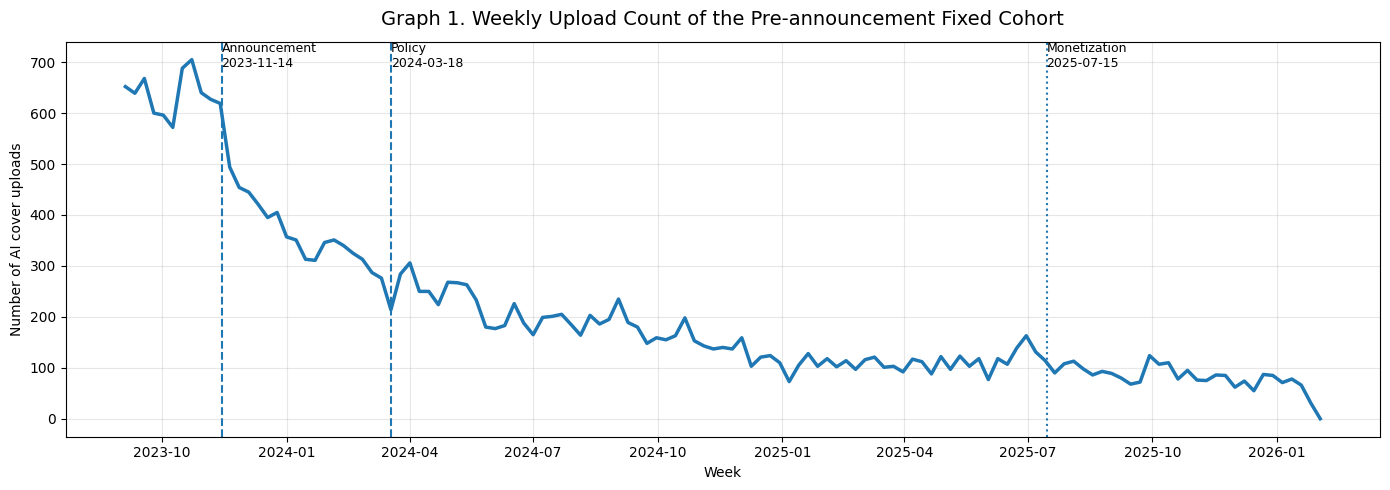

In [10]:
# =========================================================
# Graph 1. Weekly Upload Count
# =========================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_uploads["week"].dt.tz_localize(None),
    weekly_uploads["cohort_uploads"],
    linewidth=2.5
)

add_policy_lines(ax)

format_axis(
    ax,
    title="Graph 1. Weekly Upload Count of the Pre-announcement Fixed Cohort",
    xlabel="Week",
    ylabel="Number of AI cover uploads"
)

save_figure(fig, "01_weekly_upload_count_fixed_cohort.png")
plt.show()

In [11]:
# =========================================================
# 8. Weekly Active Channel Count of Fixed Cohort
# =========================================================

weekly_active_raw = (
    cohort_ai_window
    .groupby("week", as_index=False)
    .agg(
        cohort_active_channels=("channel_id", "nunique")
    )
    .sort_values("week")
)

weekly_active = complete_weekly_series(
    weekly_active_raw,
    week_col="week",
    fill_cols=["cohort_active_channels"]
)

weekly_active["cohort_active_channels"] = weekly_active["cohort_active_channels"].astype(int)

display(weekly_active.head())
display(weekly_active.tail())

,week,cohort_active_channels
0,2023-09-04 00:00:00+00:00,222
1,2023-09-11 00:00:00+00:00,216
2,2023-09-18 00:00:00+00:00,205
3,2023-09-25 00:00:00+00:00,193
4,2023-10-02 00:00:00+00:00,202


,week,cohort_active_channels
122,2026-01-05 00:00:00+00:00,38
123,2026-01-12 00:00:00+00:00,33
124,2026-01-19 00:00:00+00:00,33
125,2026-01-26 00:00:00+00:00,19
126,2026-02-02 00:00:00+00:00,0


Saved figure: pre_announcement_fixed_cohort_outputs/02_weekly_active_channel_count_fixed_cohort.png


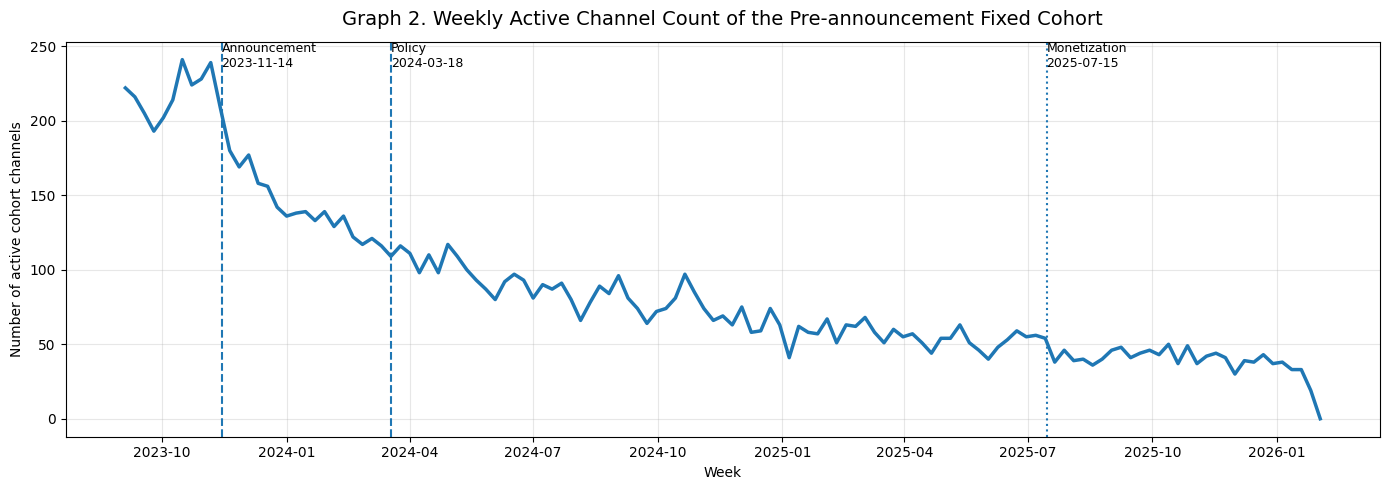

In [12]:
# =========================================================
# Graph 2. Weekly Active Channel Count
# =========================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_active["week"].dt.tz_localize(None),
    weekly_active["cohort_active_channels"],
    linewidth=2.5
)

add_policy_lines(ax)

format_axis(
    ax,
    title="Graph 2. Weekly Active Channel Count of the Pre-announcement Fixed Cohort",
    xlabel="Week",
    ylabel="Number of active cohort channels"
)

save_figure(fig, "02_weekly_active_channel_count_fixed_cohort.png")
plt.show()

In [13]:
# =========================================================
# 9. Average Uploads per Active Channel
# =========================================================

weekly_avg = (
    weekly_uploads
    .merge(weekly_active, on="week", how="outer")
    .sort_values("week")
)

weekly_avg["avg_uploads_per_active_channel"] = (
    weekly_avg["cohort_uploads"] /
    weekly_avg["cohort_active_channels"].replace(0, np.nan)
)

display(weekly_avg.head())
display(weekly_avg.tail())

,week,cohort_uploads,cohort_active_channels,avg_uploads_per_active_channel
0,2023-09-04 00:00:00+00:00,652,222,2.936937
1,2023-09-11 00:00:00+00:00,639,216,2.958333
2,2023-09-18 00:00:00+00:00,668,205,3.258537
3,2023-09-25 00:00:00+00:00,600,193,3.108808
4,2023-10-02 00:00:00+00:00,596,202,2.950495


,week,cohort_uploads,cohort_active_channels,avg_uploads_per_active_channel
122,2026-01-05 00:00:00+00:00,71,38,1.868421
123,2026-01-12 00:00:00+00:00,78,33,2.363636
124,2026-01-19 00:00:00+00:00,66,33,2.000000
125,2026-01-26 00:00:00+00:00,31,19,1.631579
126,2026-02-02 00:00:00+00:00,0,0,NaN


Saved figure: pre_announcement_fixed_cohort_outputs/03_average_uploads_per_active_channel_fixed_cohort.png


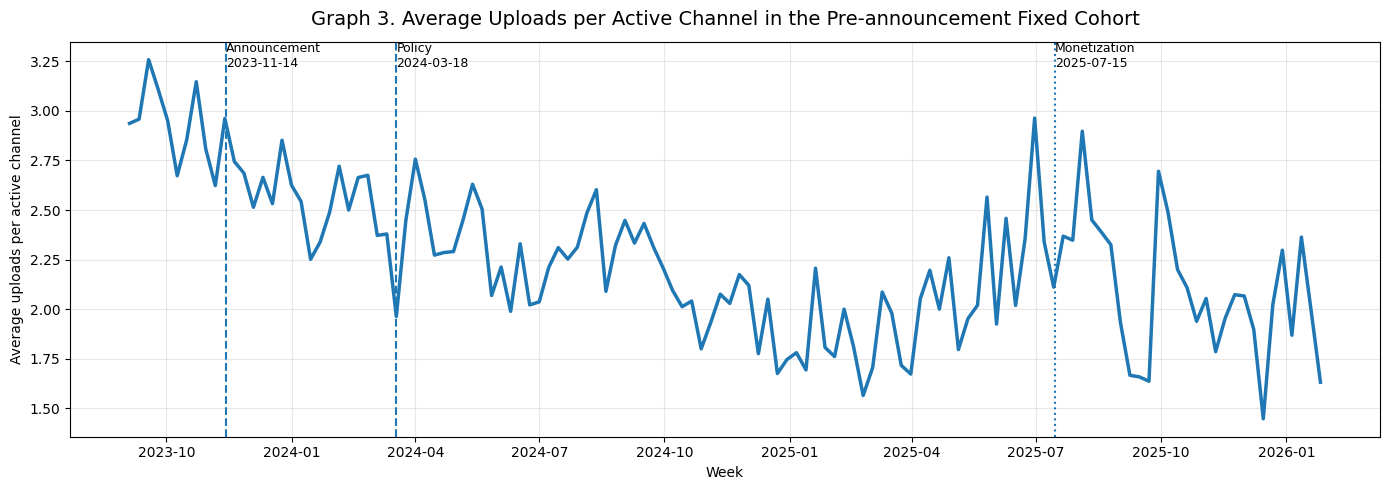

In [14]:
# =========================================================
# Graph 3. Average Uploads per Active Channel
# =========================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_avg["week"].dt.tz_localize(None),
    weekly_avg["avg_uploads_per_active_channel"],
    linewidth=2.5
)

add_policy_lines(ax)

format_axis(
    ax,
    title="Graph 3. Average Uploads per Active Channel in the Pre-announcement Fixed Cohort",
    xlabel="Week",
    ylabel="Average uploads per active channel"
)

save_figure(fig, "03_average_uploads_per_active_channel_fixed_cohort.png")
plt.show()

In [15]:
# =========================================================
# 10. Channel-week Panel for HHI and Gini
# =========================================================

channel_week_uploads = (
    cohort_ai_window
    .groupby(["week", "channel_id"], as_index=False)
    .agg(
        uploads=("video_id", "count")
    )
    .sort_values(["week", "channel_id"])
)

all_weeks = pd.date_range(
    start=first_full_monday(ANALYSIS_START_RAW),
    end=first_full_monday(ANALYSIS_END_RAW),
    freq="W-MON",
    tz="UTC"
)

all_cohort_channels = sorted(list(pre_announcement_fixed_cohort_ids))

channel_week_index = pd.MultiIndex.from_product(
    [all_weeks, all_cohort_channels],
    names=["week", "channel_id"]
)

channel_week_panel = (
    channel_week_uploads
    .set_index(["week", "channel_id"])
    .reindex(channel_week_index)
    .fillna({"uploads": 0})
    .reset_index()
)

channel_week_panel["uploads"] = channel_week_panel["uploads"].astype(int)

print("channel_week_panel shape:", channel_week_panel.shape)
display(channel_week_panel.head())

channel_week_panel shape: (101092, 3)


,week,channel_id,uploads
0,2023-09-04 00:00:00+00:00,UC-26K0B-XV5ieqZsQ3QPrcA,1
1,2023-09-04 00:00:00+00:00,UC-58AFr18tKsOo6dlp9GlXA,0
2,2023-09-04 00:00:00+00:00,UC-6Gn8Gjk6c-ZPEdI-Bin-A,0
3,2023-09-04 00:00:00+00:00,UC-6uc1nMrLJUWjj5hHH5hxw,1
4,2023-09-04 00:00:00+00:00,UC-9H1PtHJ79--fnmknYmsyQ,0


In [16]:
# =========================================================
# 11. Weekly HHI of Fixed Cohort
# =========================================================

weekly_hhi = (
    channel_week_panel
    .groupby("week", as_index=False)
    .agg(
        cohort_hhi=("uploads", calculate_hhi_from_counts),
        cohort_uploads=("uploads", "sum"),
        cohort_active_channels=("uploads", lambda x: int((x > 0).sum()))
    )
    .sort_values("week")
)

weekly_hhi.loc[weekly_hhi["cohort_uploads"] <= 0, "cohort_hhi"] = np.nan

display(weekly_hhi.head())
display(weekly_hhi.tail())

,week,cohort_hhi,cohort_uploads,cohort_active_channels
0,2023-09-04 00:00:00+00:00,0.015850,652,222
1,2023-09-11 00:00:00+00:00,0.032154,639,216
2,2023-09-18 00:00:00+00:00,0.028380,668,205
3,2023-09-25 00:00:00+00:00,0.024211,600,193
4,2023-10-02 00:00:00+00:00,0.023518,596,202


,week,cohort_hhi,cohort_uploads,cohort_active_channels
122,2026-01-05 00:00:00+00:00,0.041460,71,38
123,2026-01-12 00:00:00+00:00,0.092702,78,33
124,2026-01-19 00:00:00+00:00,0.047750,66,33
125,2026-01-26 00:00:00+00:00,0.100937,31,19
126,2026-02-02 00:00:00+00:00,NaN,0,0


Saved figure: pre_announcement_fixed_cohort_outputs/04_weekly_hhi_fixed_cohort.png


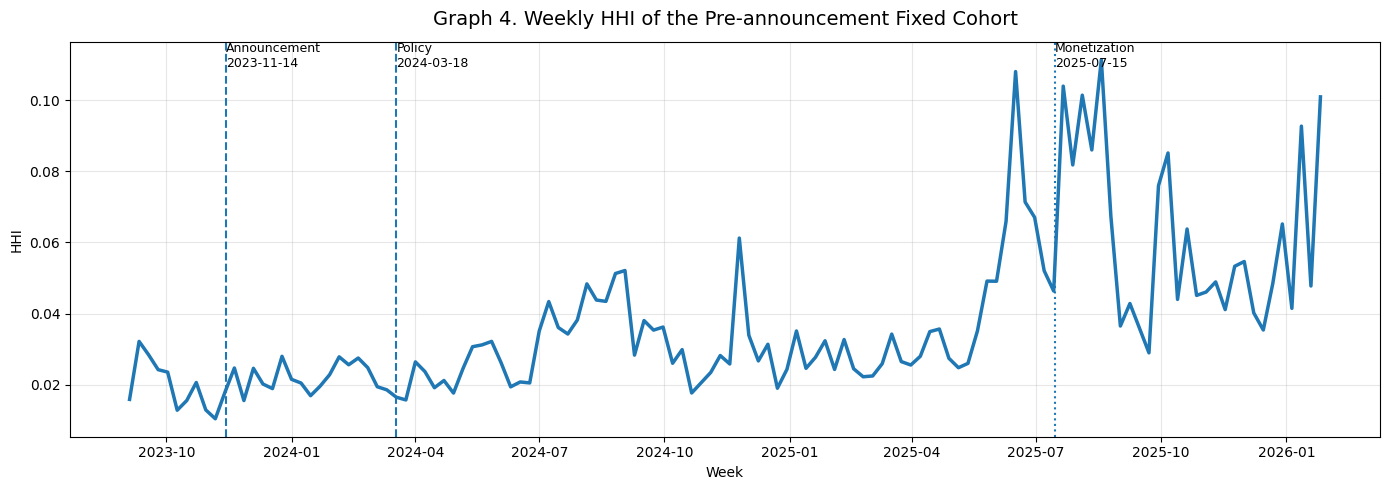

In [17]:
# =========================================================
# Graph 4. Weekly HHI
# =========================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_hhi["week"].dt.tz_localize(None),
    weekly_hhi["cohort_hhi"],
    linewidth=2.5
)

add_policy_lines(ax)

format_axis(
    ax,
    title="Graph 4. Weekly HHI of the Pre-announcement Fixed Cohort",
    xlabel="Week",
    ylabel="HHI"
)

save_figure(fig, "04_weekly_hhi_fixed_cohort.png")
plt.show()

In [18]:
# =========================================================
# 12. Weekly Gini of Fixed Cohort
# =========================================================

weekly_gini = (
    channel_week_panel
    .groupby("week", as_index=False)
    .agg(
        cohort_gini=("uploads", calculate_gini_from_counts),
        cohort_uploads=("uploads", "sum"),
        cohort_active_channels=("uploads", lambda x: int((x > 0).sum()))
    )
    .sort_values("week")
)

weekly_gini.loc[weekly_gini["cohort_uploads"] <= 0, "cohort_gini"] = np.nan

display(weekly_gini.head())
display(weekly_gini.tail())

,week,cohort_gini,cohort_uploads,cohort_active_channels
0,2023-09-04 00:00:00+00:00,0.862456,652,222
1,2023-09-11 00:00:00+00:00,0.876497,639,216
2,2023-09-18 00:00:00+00:00,0.891700,668,205
3,2023-09-25 00:00:00+00:00,0.890833,600,193
4,2023-10-02 00:00:00+00:00,0.879945,596,202


,week,cohort_gini,cohort_uploads,cohort_active_channels
122,2026-01-05 00:00:00+00:00,0.968876,71,38
123,2026-01-12 00:00:00+00:00,0.978514,78,33
124,2026-01-19 00:00:00+00:00,0.973009,66,33
125,2026-01-26 00:00:00+00:00,0.984155,31,19
126,2026-02-02 00:00:00+00:00,NaN,0,0


Saved figure: pre_announcement_fixed_cohort_outputs/05_weekly_gini_fixed_cohort.png


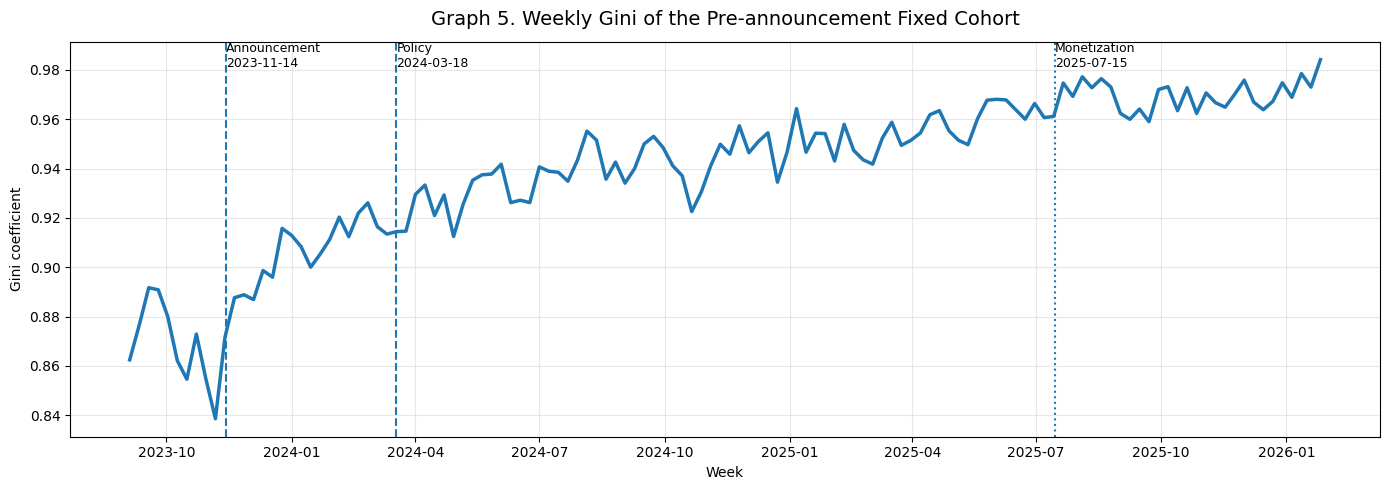

In [19]:
# =========================================================
# Graph 5. Weekly Gini
# =========================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_gini["week"].dt.tz_localize(None),
    weekly_gini["cohort_gini"],
    linewidth=2.5
)

add_policy_lines(ax)

format_axis(
    ax,
    title="Graph 5. Weekly Gini of the Pre-announcement Fixed Cohort",
    xlabel="Week",
    ylabel="Gini coefficient"
)

save_figure(fig, "05_weekly_gini_fixed_cohort.png")
plt.show()

In [20]:
# =========================================================
# 13. Combined Weekly Dataset
# =========================================================

weekly_fixed_cohort = (
    weekly_uploads
    .merge(weekly_active, on="week", how="outer")
    .merge(
        weekly_avg[["week", "avg_uploads_per_active_channel"]],
        on="week",
        how="outer"
    )
    .merge(
        weekly_hhi[["week", "cohort_hhi"]],
        on="week",
        how="outer"
    )
    .merge(
        weekly_gini[["week", "cohort_gini"]],
        on="week",
        how="outer"
    )
    .sort_values("week")
    .reset_index(drop=True)
)

weekly_fixed_cohort["post_announcement"] = (
    weekly_fixed_cohort["week"] >= PRE_ANNOUNCEMENT_DATE
).astype(int)

weekly_fixed_cohort["post_policy"] = (
    weekly_fixed_cohort["week"] >= POLICY_DATE
).astype(int)

weekly_fixed_cohort["post_policy2"] = (
    weekly_fixed_cohort["week"] >= POLICY2_DATE
).astype(int)

weekly_fixed_cohort["week_index"] = np.arange(len(weekly_fixed_cohort))

weekly_fixed_cohort["weeks_from_announcement"] = (
    (weekly_fixed_cohort["week"] - PRE_ANNOUNCEMENT_DATE).dt.days / 7
)

weekly_fixed_cohort["weeks_from_policy"] = (
    (weekly_fixed_cohort["week"] - POLICY_DATE).dt.days / 7
)

weekly_fixed_cohort["weeks_from_policy2"] = (
    (weekly_fixed_cohort["week"] - POLICY2_DATE).dt.days / 7
)

display(weekly_fixed_cohort.head())
display(weekly_fixed_cohort.tail())

,week,cohort_uploads,cohort_active_channels,avg_uploads_per_active_channel,cohort_hhi,cohort_gini,post_announcement,post_policy,post_policy2,week_index,weeks_from_announcement,weeks_from_policy,weeks_from_policy2
0,2023-09-04 00:00:00+00:00,652,222,2.936937,0.015850,0.862456,0,0,0,0,-10.142857,-28.0,-97.142857
1,2023-09-11 00:00:00+00:00,639,216,2.958333,0.032154,0.876497,0,0,0,1,-9.142857,-27.0,-96.142857
2,2023-09-18 00:00:00+00:00,668,205,3.258537,0.028380,0.891700,0,0,0,2,-8.142857,-26.0,-95.142857
3,2023-09-25 00:00:00+00:00,600,193,3.108808,0.024211,0.890833,0,0,0,3,-7.142857,-25.0,-94.142857
4,2023-10-02 00:00:00+00:00,596,202,2.950495,0.023518,0.879945,0,0,0,4,-6.142857,-24.0,-93.142857


,week,cohort_uploads,cohort_active_channels,avg_uploads_per_active_channel,cohort_hhi,cohort_gini,post_announcement,post_policy,post_policy2,week_index,weeks_from_announcement,weeks_from_policy,weeks_from_policy2
122,2026-01-05 00:00:00+00:00,71,38,1.868421,0.041460,0.968876,1,1,1,122,111.857143,94.0,24.857143
123,2026-01-12 00:00:00+00:00,78,33,2.363636,0.092702,0.978514,1,1,1,123,112.857143,95.0,25.857143
124,2026-01-19 00:00:00+00:00,66,33,2.000000,0.047750,0.973009,1,1,1,124,113.857143,96.0,26.857143
125,2026-01-26 00:00:00+00:00,31,19,1.631579,0.100937,0.984155,1,1,1,125,114.857143,97.0,27.857143
126,2026-02-02 00:00:00+00:00,0,0,NaN,NaN,NaN,1,1,1,126,115.857143,98.0,28.857143


In [21]:
# =========================================================
# 14. Period Summary Table
# =========================================================

def period_label(week):
    if week < PRE_ANNOUNCEMENT_DATE:
        return "1_pre_announcement"
    elif week < POLICY_DATE:
        return "2_announcement_to_policy"
    elif week < POLICY2_DATE:
        return "3_post_policy1"
    else:
        return "4_post_policy2"


weekly_fixed_cohort["period"] = weekly_fixed_cohort["week"].apply(period_label)

summary_by_period = (
    weekly_fixed_cohort
    .groupby("period", as_index=False)
    .agg(
        weeks=("week", "count"),
        mean_uploads=("cohort_uploads", "mean"),
        median_uploads=("cohort_uploads", "median"),
        mean_active_channels=("cohort_active_channels", "mean"),
        median_active_channels=("cohort_active_channels", "median"),
        mean_avg_uploads_per_active_channel=("avg_uploads_per_active_channel", "mean"),
        median_avg_uploads_per_active_channel=("avg_uploads_per_active_channel", "median"),
        mean_hhi=("cohort_hhi", "mean"),
        median_hhi=("cohort_hhi", "median"),
        mean_gini=("cohort_gini", "mean"),
        median_gini=("cohort_gini", "median")
    )
)

display(summary_by_period)

,period,weeks,mean_uploads,median_uploads,mean_active_channels,median_active_channels,mean_avg_uploads_per_active_channel,median_avg_uploads_per_active_channel,mean_hhi,median_hhi,mean_gini,median_gini
0,1_pre_announcement,11,636.909091,639.0,217.545455,216.0,2.934570,2.950495,0.019464,0.017781,0.868717,0.871565
1,2_announcement_to_policy,17,363.764706,351.0,141.647059,138.0,2.561929,2.543478,0.022155,0.021491,0.907180,0.911305
2,3_post_policy1,70,158.171429,145.5,73.128571,68.5,2.135134,2.092241,0.033654,0.029075,0.945057,0.946467
3,4_post_policy2,29,80.758621,85.0,38.517241,40.0,2.091713,2.060360,0.061647,0.051088,0.969928,0.970386


In [22]:
# =========================================================
# 15. Top 10 Pre-announcement Channel Upload Share
# =========================================================

pre_period_channel_rank = (
    pre_period_ai
    .groupby("channel_id", as_index=False)
    .agg(
        pre_period_uploads=("video_id", "count")
    )
    .sort_values("pre_period_uploads", ascending=False)
    .reset_index(drop=True)
)

top10_pre_channels = set(
    pre_period_channel_rank.head(10)["channel_id"].astype(str)
)

cohort_ai_window_for_top = cohort_ai_window.copy()

cohort_ai_window_for_top["is_top10_pre_channel"] = (
    cohort_ai_window_for_top["channel_id"].astype(str).isin(top10_pre_channels)
).astype(int)

weekly_top10_share_raw = (
    cohort_ai_window_for_top
    .groupby(["week", "is_top10_pre_channel"], as_index=False)
    .agg(
        uploads=("video_id", "count")
    )
)

weekly_top10_pivot = (
    weekly_top10_share_raw
    .pivot(index="week", columns="is_top10_pre_channel", values="uploads")
    .fillna(0)
    .reset_index()
)

if 0 not in weekly_top10_pivot.columns:
    weekly_top10_pivot[0] = 0

if 1 not in weekly_top10_pivot.columns:
    weekly_top10_pivot[1] = 0

weekly_top10_pivot = weekly_top10_pivot.rename(
    columns={
        0: "non_top10_uploads",
        1: "top10_uploads"
    }
)

weekly_top10_pivot["total_uploads"] = (
    weekly_top10_pivot["top10_uploads"] +
    weekly_top10_pivot["non_top10_uploads"]
)

weekly_top10_pivot = complete_weekly_series(
    weekly_top10_pivot,
    week_col="week",
    fill_cols=["top10_uploads", "non_top10_uploads", "total_uploads"]
)

weekly_top10_pivot["top10_upload_share"] = (
    weekly_top10_pivot["top10_uploads"] /
    weekly_top10_pivot["total_uploads"].replace(0, np.nan)
)

print("Top 10 pre-announcement channels:")
display(pre_period_channel_rank.head(10))

display(weekly_top10_pivot.head())
display(weekly_top10_pivot.tail())

Top 10 pre-announcement channels:


,channel_id,pre_period_uploads
0,UCwC0dvNBcVzhLr-zs3FolOA,489
1,UCfHiutp6YEutVFL6GJIzcHg,265
2,UChLdcwwoKH9SAebjFwB4QJw,217
3,UCyzvitoJFMVgOU2CjVGDymQ,145
4,UCc4g0JH2RWzcN9wXh7vUlGQ,132
5,UCIC9vGQkmXrm-OoikQdJcaw,121
6,UCX-WouaPlOeRVnI60Glgd0g,108
7,UCWi0NHCcwJ1m9llZQclFp6A,101
8,UCqxp6ak3TKvqCIJOSwU54UA,85
9,UCPFFm0FMZQpCw4DRdLr_zcw,76


is_top10_pre_channel,week,non_top10_uploads,top10_uploads,total_uploads,top10_upload_share
0,2023-09-04 00:00:00+00:00,539.0,113.0,652.0,0.173313
1,2023-09-11 00:00:00+00:00,444.0,195.0,639.0,0.305164
2,2023-09-18 00:00:00+00:00,450.0,218.0,668.0,0.326347
3,2023-09-25 00:00:00+00:00,423.0,177.0,600.0,0.295000
4,2023-10-02 00:00:00+00:00,428.0,168.0,596.0,0.281879


is_top10_pre_channel,week,non_top10_uploads,top10_uploads,total_uploads,top10_upload_share
122,2026-01-05 00:00:00+00:00,71.0,0.0,71.0,0.0
123,2026-01-12 00:00:00+00:00,78.0,0.0,78.0,0.0
124,2026-01-19 00:00:00+00:00,66.0,0.0,66.0,0.0
125,2026-01-26 00:00:00+00:00,31.0,0.0,31.0,0.0
126,2026-02-02 00:00:00+00:00,0.0,0.0,0.0,NaN


Saved figure: pre_announcement_fixed_cohort_outputs/06_top10_pre_channel_upload_share_fixed_cohort.png


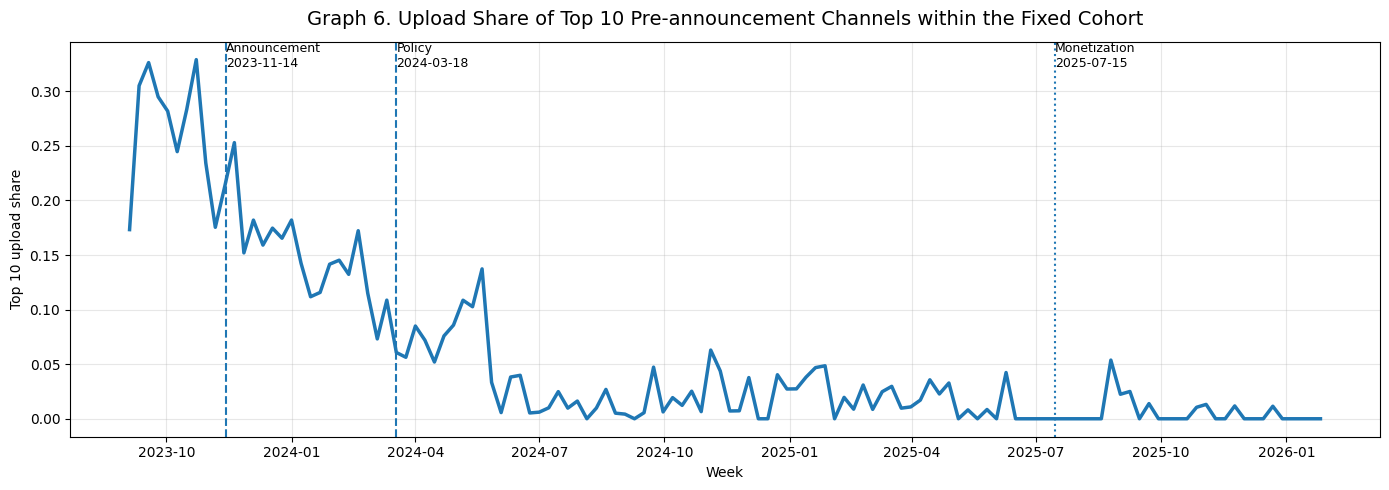

In [23]:
# =========================================================
# Graph 6. Top 10 Pre-announcement Channel Upload Share
# =========================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_top10_pivot["week"].dt.tz_localize(None),
    weekly_top10_pivot["top10_upload_share"],
    linewidth=2.5
)

add_policy_lines(ax)

format_axis(
    ax,
    title="Graph 6. Upload Share of Top 10 Pre-announcement Channels within the Fixed Cohort",
    xlabel="Week",
    ylabel="Top 10 upload share"
)

save_figure(fig, "06_top10_pre_channel_upload_share_fixed_cohort.png")
plt.show()

In [ ]:
# =========================================================
# Final Summary
# =========================================================

print("=========================================================")
print("Pre-announcement Fixed Cohort Analysis Summary")
print("=========================================================")
print(f"Fixed cohort definition period: {PRE_ACTIVE_START.date()} ~ {PRE_ACTIVE_END.date()}")
print(f"Fixed cohort size: {cohort_size:,} channels")
print(f"Total AI cover uploads by fixed cohort in analysis window: {len(cohort_ai_window):,}")
print("---------------------------------------------------------")
print("Period summary:")
display(summary_by_period)

Pre-announcement Fixed Cohort Analysis Summary
Fixed cohort definition period: 2023-09-01 ~ 2023-11-13
Fixed cohort size: 796 channels
Total AI cover uploads by fixed cohort in analysis window: 26,604
---------------------------------------------------------
Period summary:


,period,weeks,mean_uploads,median_uploads,mean_active_channels,median_active_channels,mean_avg_uploads_per_active_channel,median_avg_uploads_per_active_channel,mean_hhi,median_hhi,mean_gini,median_gini
0,1_pre_announcement,11,636.909091,639.0,217.545455,216.0,2.934570,2.950495,0.019464,0.017781,0.868717,0.871565
1,2_announcement_to_policy,17,363.764706,351.0,141.647059,138.0,2.561929,2.543478,0.022155,0.021491,0.907180,0.911305
2,3_post_policy1,70,158.171429,145.5,73.128571,68.5,2.135134,2.092241,0.033654,0.029075,0.945057,0.946467
3,4_post_policy2,29,80.758621,85.0,38.517241,40.0,2.091713,2.060360,0.061647,0.051088,0.969928,0.970386
